# Supplementary Figure S25: LR-complex aggregation

Load paired LR scores, recalculate the panel tables, and reproduce the manuscript figure.

## Reproduction route

This route states where the plotted values begin, how the upstream analysis is
run when it is available, and what this notebook does not recalculate.

In [1]:
from CytoBridge.results import describe_figure_workflow

route = describe_figure_workflow('lr-complex')
{
    key: route[key]
    for key in (
        "paper_location",
        "mode",
        "starts_from",
        "upstream_entry",
        "upstream_command",
        "figure_command",
        "scope",
    )
}

{'paper_location': 'Supplementary Figure S25',
 'mode': 'numeric-redraw',
 'starts_from': 'Packaged paired minimum-subunit and geometric-mean LR scores.',
 'upstream_entry': 'scripts/run_lr_complex_aggregation_sensitivity.py',
 'upstream_command': 'python scripts/run_lr_complex_aggregation_sensitivity.py --workflow-summary <downstream-summary.json> --output-dir <sensitivity-dir>',
 'figure_command': 'cytobridge figure lr-complex --output-dir outputs/lr_complex',
 'scope': 'Redraws S25. Fresh sensitivity tables require completed spatial downstream runs.'}

## Imports and configuration

In [2]:
from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    load_lr_complex_aggregation_results,
    plot_lr_complex_aggregation,
)
from CytoBridge.results.lr_complex_aggregation import (
    summarize_lr_complex_aggregation,
    write_lr_complex_aggregation_tables,
)

output_dir = Path("outputs") / "lr_complex_aggregation"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [3]:
results = load_lr_complex_aggregation_results()
display(
    results.paired_scores[
        ["dataset", "time", "pair", "score_min", "score_geometric_mean", "is_multisubunit"]
    ].head()
)

,dataset,time,pair,score_min,score_geometric_mean,is_multisubunit
0,zebrafish,0.0,adcyap1a_adcyap1r1a,0.0,0.0,False
1,zebrafish,0.0,adipoqb_adipor1a,0.0,0.0,False
2,zebrafish,0.0,adipoqb_adipor1b,0.0,0.0,False
3,zebrafish,0.0,adipoqb_adipor2,0.0,0.0,False
4,zebrafish,0.0,adma_calcr,0.0,0.0,False


## Recalculate panel data

Spearman correlation is calculated once over all pair-time rows and separately at each time. Top sets use `min(n, max(1, min(10, ceil(0.2 n))))` pairs with pair name as the tie break. Time is normalized within each dataset.

In [4]:
per_time, dataset_summary = summarize_lr_complex_aggregation(results.paired_scores)
display(dataset_summary)
display(per_time.loc[per_time["scope"].eq("all_scored_pairs")].head(12))

,dataset,n_scored_pairs,n_multisubunit_pairs,pooled_spearman,min_per_time_spearman,min_top10_jaccard
0,Zebrafish,1832,973,0.998558,0.954636,1.000000
1,MOSTA,1757,887,0.984745,0.982595,1.000000
2,ARISTA,531,293,0.960106,0.950453,0.666667
3,Chicken Heart,745,386,0.977109,0.957120,0.428571


,dataset,time,normalized_time,scope,n_pairs,spearman,top_n,top_overlap_n,top_jaccard
0,Zebrafish,0.0,0.000000,all_scored_pairs,1832,0.999994,10,10,1.0
2,Zebrafish,0.5,0.125000,all_scored_pairs,1832,0.960729,10,10,1.0
4,Zebrafish,1.0,0.250000,all_scored_pairs,1832,NaN,10,10,1.0
6,Zebrafish,1.5,0.375000,all_scored_pairs,1832,NaN,10,10,1.0
8,Zebrafish,2.0,0.500000,all_scored_pairs,1832,0.999921,10,10,1.0
10,Zebrafish,2.5,0.625000,all_scored_pairs,1832,0.954636,10,10,1.0
12,Zebrafish,3.0,0.750000,all_scored_pairs,1832,0.993753,10,10,1.0
14,Zebrafish,3.5,0.875000,all_scored_pairs,1832,0.956563,10,10,1.0
16,Zebrafish,4.0,1.000000,all_scored_pairs,1832,0.976764,10,10,1.0
18,MOSTA,0.0,0.000000,all_scored_pairs,1757,0.982595,10,10,1.0


## Render and save the figure

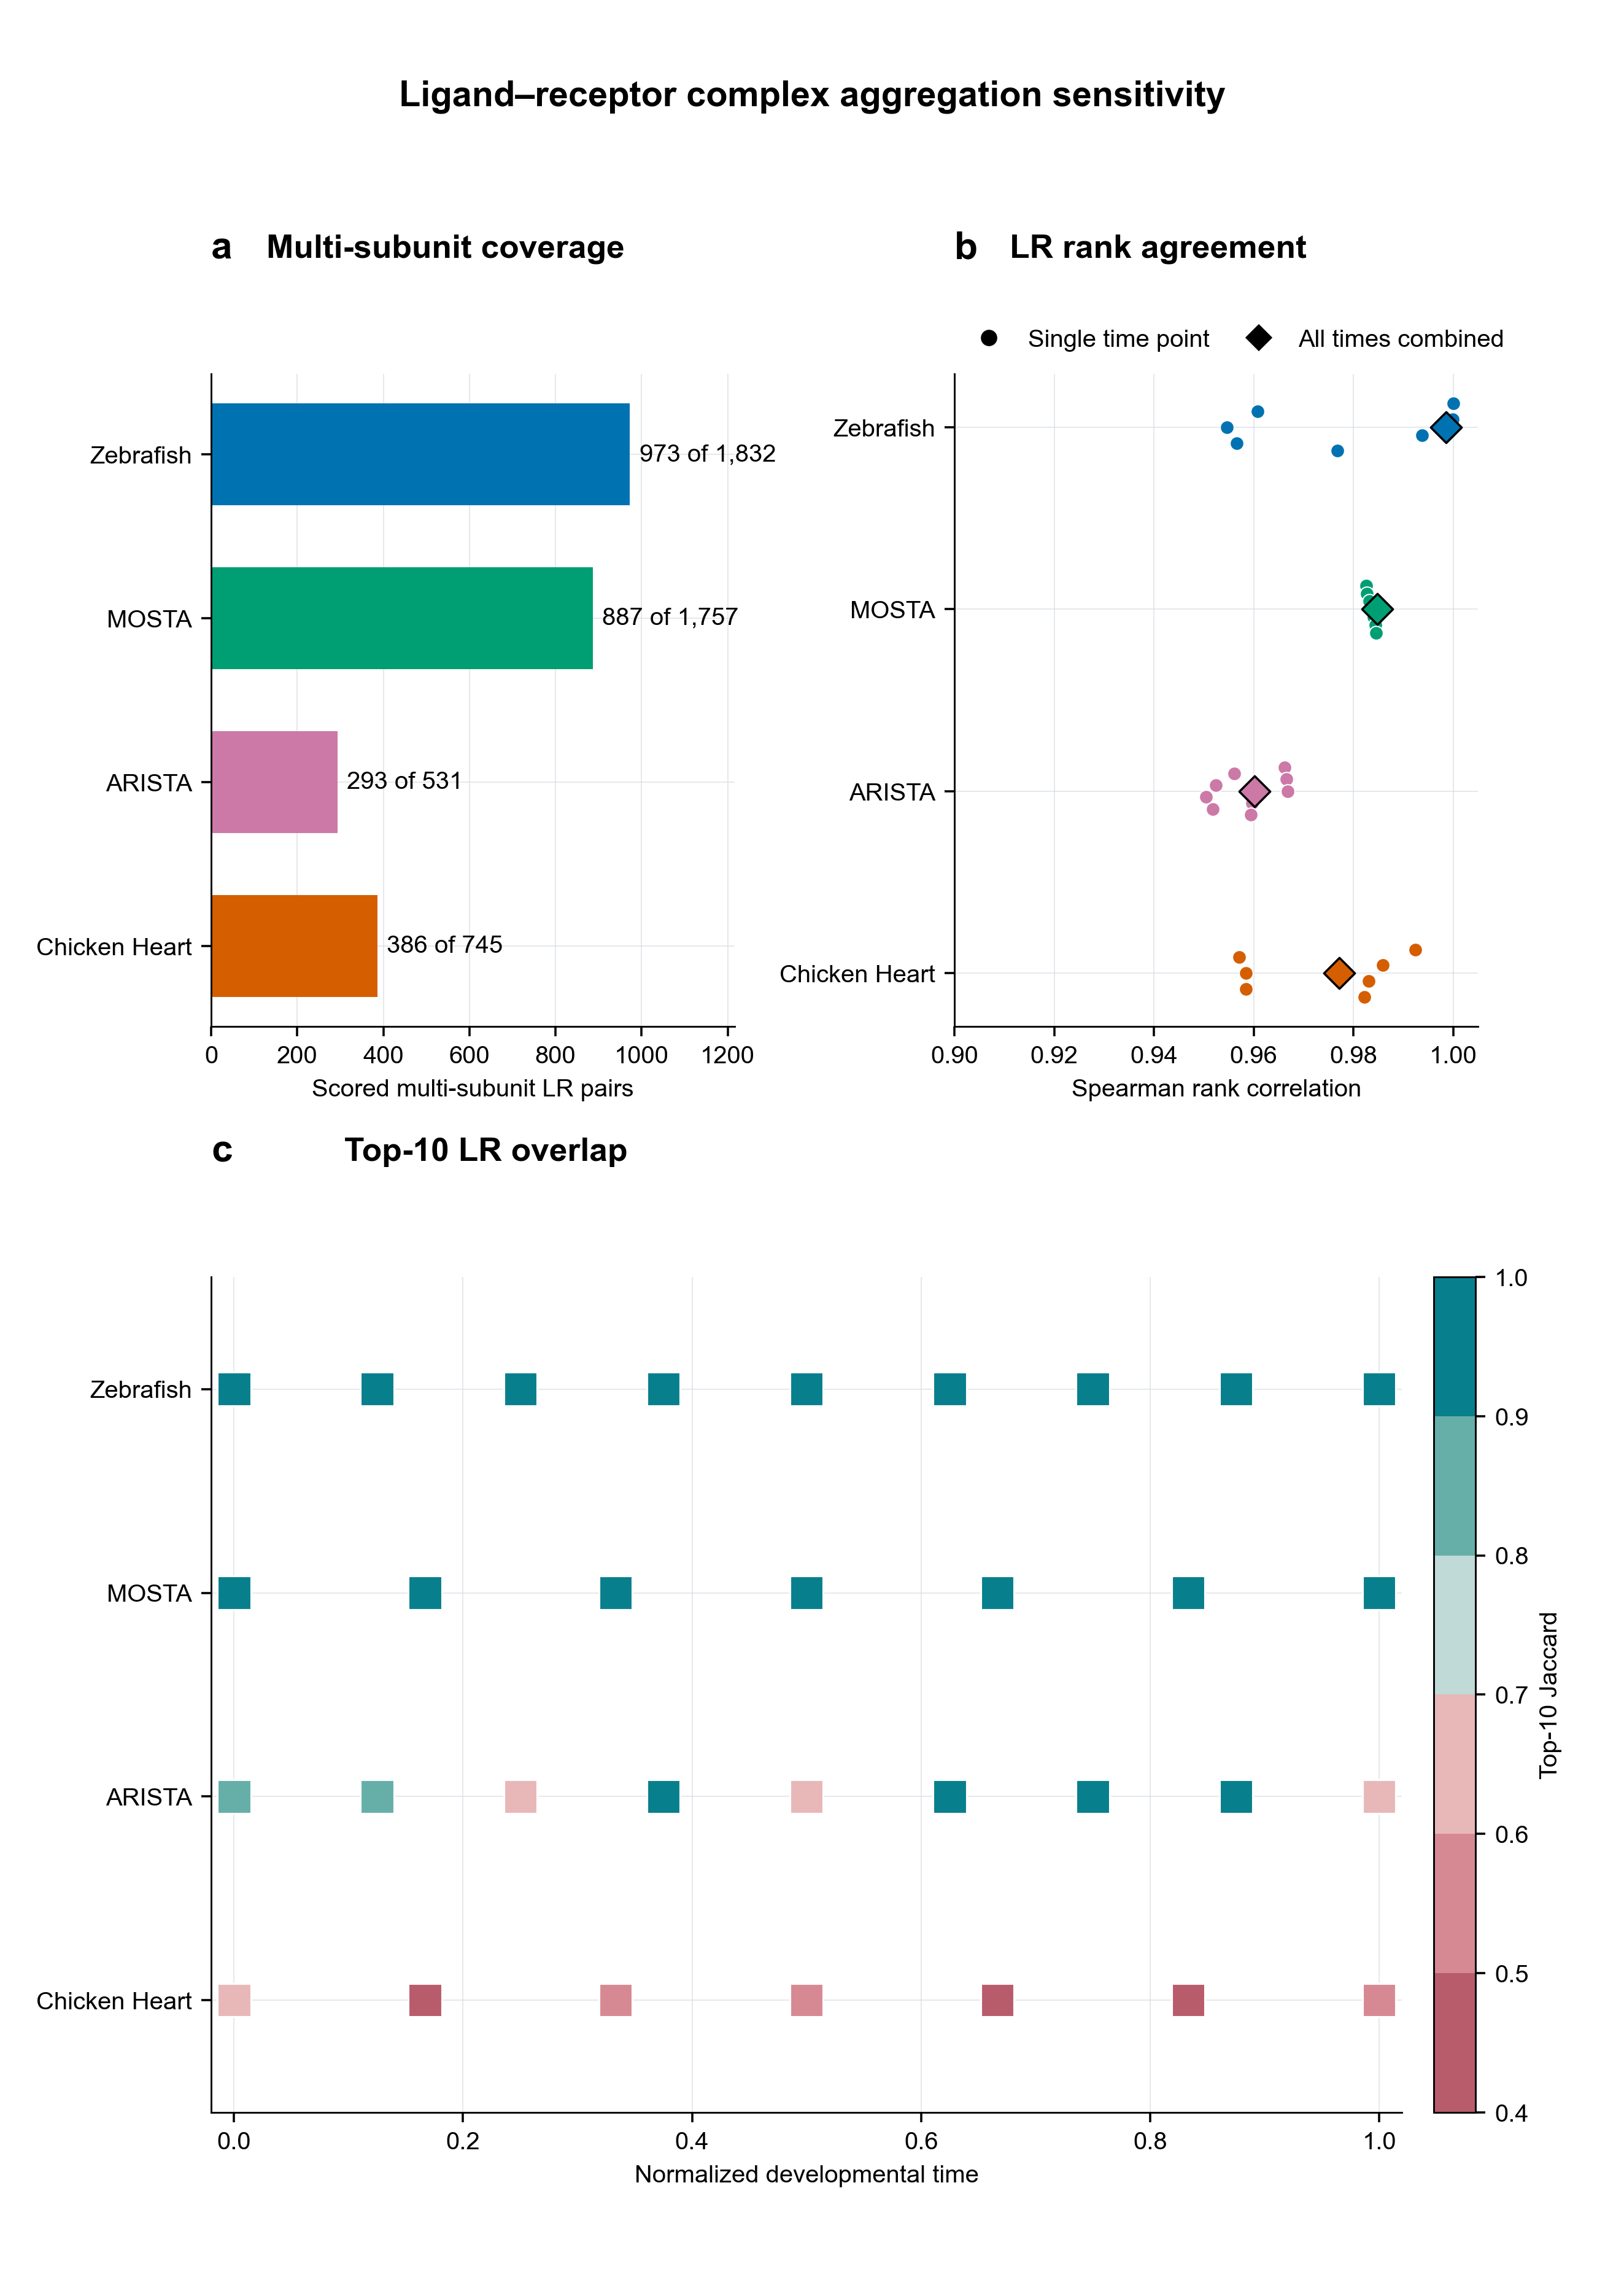

In [5]:
table_paths = write_lr_complex_aggregation_tables(results, output_dir)
pdf_path, png_path = plot_lr_complex_aggregation(results, output_dir)
display(Image(filename=str(png_path), width=700))

## Check outputs

In [6]:
{
    "pair_time_rows": len(results.paired_scores),
    "per_time_rows": len(per_time),
    "dataset_rows": len(dataset_summary),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'pair_time_rows': 38781,
 'per_time_rows': 64,
 'dataset_rows': 4,
 'tables': {'per_time': True, 'dataset_summary': True},
 'pdf': True,
 'png': True}

## Upstream analysis and API

The command-line entry is `scripts/results/plot_lr_complex_aggregation.py`. The reader API is in `CytoBridge/results/lr_complex_aggregation.py`. LR-score calculation is upstream of the packaged paired tables.